#### Task Description:
Use the previously-trained ML methods to recognize Fe deficiency in sheets 1,2,4 (as individual test sets) based on the different hyperspectral spectra (i.e., measuring leaf reflectance at different wavelengths in the range of 400 to 1000 nm) in 3 following modes:
#### 1) include all Wavelengths (from X397.32 to X1003.58 is included)
#### 2) remove nosiy Wavelengths (from X449.35 to X951.17 is included)
#### 3) 9 SHAP Features in 1&2 (Remember to Remove "reduced-related" codes when execute these states)

#### <font color=red> The SHAP plots are for class [1] which is "Fe deficiency" here </font>

#### Methods
- Logistic Regression (Linear)
- Random Forest
#### Test States: 1) All 2) Some

In [111]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer,  precision_score,  recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
# Initialize JavaScript for SHAP visualizations
shap.initjs()


#### Save each sheet as a separate .txt

In [2]:
# excel_file = 'mix_data_HIS_Fe_deficiency_Zanin_1.xlsx'

# # Load the Excel file
# excel_data = pd.ExcelFile(excel_file)

# # Loop through each sheet in the Excel file
# for sheet_name in excel_data.sheet_names:
#     # Read the sheet into a DataFrame
#     df = excel_data.parse(sheet_name)
    
#     # Define the output file name (based on sheet name)
#     output_file = f"{sheet_name}.txt"
    
#     # Save the DataFrame as a tab-delimited .txt file
#     df.to_csv(output_file, sep='\t', index=False)
#     print(f"Sheet '{sheet_name}' has been saved as '{output_file}'")


#### Load and Preprocess
- Drop the 'Leaf' column as it provides no classification information (it has the same value 'YL' for all rows)
- Encode the 'Thesis' column (the ground-truth label)
- Separate the dataset into features and labels
- check class imbalance 1) in the whole dataset 2) per each plant
- Check for missing values in the entire DataFrame (There was none)
- Identify outliers using the IQR method ---> <font color=red> NOT SURE. Do I drop them? </font>
- Feature selection - Get feature importances using Random Forest ---> <font color=red> NOT SURE. Do I drop them? They are 165 !</font>
- Scale the feature values (Columns here)
##### <font color=red> Watch the reduced variables (X_reduced, feature_names_reduced, X_scaled after reducing dimensions) for execution </font>
##### <font color=red> Watch the consistency between encoded labels of the original dataset and the new one for execution </font>

['X714.55', 'X702.58', 'X708.57', 'X711.56', 'X705.57', 'X566.18', 'X699.60', 'X589.75', 'X580.90']
Class Distribution:
Thesis
+N+Fe    72
+N-Fe    72
Name: count, dtype: int64


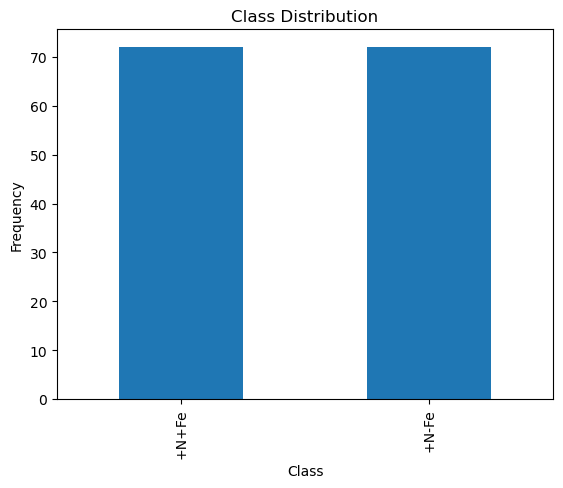

Columns with missing values: []

Number of features with 0.0 importance: 0


(144, 9)

In [145]:
# Step 1: Load the dataset
data = pd.read_csv('Dati_HIS_Serra_Cs_Hv_Sl_Zm_no_Fe.txt', delimiter='\t')
# Step 2: Preprocess the data
# Drop the 'leaf' column
data = data.drop(columns=['Leaf'])

# 😎😎😎😎😎😎 new line, 1) include all Wavelengths
# X = data.iloc[:, 3:]  # Features
# 😎😎😎😎😎😎 new line, 2) remove nosiy Wavelengths
# X = data.iloc[:, 21:190]

# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
        #### Logistic Regression ###
# For Anna1 Dataset, All Features, Logistic Regression
# desired_columns = ['X714.55', 'X717.54', 'X985.05', 'X997.40', 'X994.31', 'X711.56', 'X978.88', 'X1000.49', 'X720.54']
# For Anna1 Dataset, Some Features, Logistic Regression
# desired_columns = ['X714.55', 'X711.56', 'X708.57', 'X720.54', 'X705.57', 'X723.53', 'X702.58', 'X750.54', 'X726.53']
# For Anna1 Dataset, All Features, Random Forest
# desired_columns = ['X705.57', 'X702.58', 'X708.57', 'X711.56', 'X714.55', 'X569.12', 'X542.68', 'X699.60', 'X545.62']
# For Anna1 Dataset, Some Features, Random Forest
# desired_columns = ['X714.55', 'X702.58', 'X711.56', 'X708.57', 'X705.57', 'X566.18', 'X699.60', 'X589.75', 'X580.90']

# For Anna2 Dataset, All Features, Logistic Regression
# desired_columns = ['X714.55', 'X717.54', 'X985.05', 'X997.40', 'X711.56', 'X994.31', 'X978.88', 'X720.54', 'X708.57']
# For Anna2 Dataset, Some Features,Logistic Regression
# desired_columns = ['X714.55', 'X711.56', 'X708.57', 'X720.54', 'X705.57', 'X723.53', 'X702.58', 'X750.54', 'X726.53']
# For Anna2 Dataset, All Features, Random Forest
# desired_columns = ['X705.57', 'X702.58', 'X708.57', 'X711.56', 'X714.55', 'X569.12', 'X542.68', 'X699.60', 'X560.30']
# For Anna2 Dataset, Some Features, Random Forest
# desired_columns = ['X714.55', 'X702.58', 'X711.56', 'X708.57', 'X705.57', 'X566.18', 'X699.60', 'X589.75', 'X580.90']

# For Marco1 Dataset, All Features, Logistic Regression
# desired_columns = ['X985.05', 'X997.40', 'X994.31', 'X714.55', 'X717.54', 'X978.88', 'X1000.49', 'X711.56', 'X819.95']
# For Marco1 Dataset, Some Features,Logistic Regression
# desired_columns = ['X714.55', 'X711.56', 'X708.57', 'X750.54', 'X720.54', 'X705.57', 'X723.53', 'X726.53', 'X702.58']
# For Marco1 Dataset, All Features, Random Forest
# desired_columns = ['X705.57', 'X708.57', 'X702.58', 'X711.56', 'X714.55', 'X569.12', 'X699.60', 'X542.68', 'X560.30']
# For Marco1 Dataset, Some Features, Random Forest
desired_columns = ['X714.55', 'X702.58', 'X708.57', 'X711.56', 'X705.57', 'X566.18', 'X699.60', 'X589.75', 'X580.90']

##### Trimmed Version####
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Anna1 Dataset, All Features, LogisticRegression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X720.54', 'X708.57', 'X723.53', 'X726.53', 'X819.95', 'X729.53']
# For Anna1 Dataset, Some Features, Logistic Regression
# desired_columns = ['X714.55', 'X753.55', 'X756.56', 'X717.54', 'X711.56', 'X708.57', 'X705.57', 'X720.54', 'X807.84']
# For Anna1 Dataset, All Features, Random Forest
# desired_columns = ['X702.58', 'X714.55', 'X705.57', 'X708.57', 'X711.56', 'X717.54', 'X563.24', 'X542.68', 'X557.36']
# For Anna1 Dataset, Some Features, Random Forest
# desired_columns = ['X711.56', 'X717.54', 'X708.57', 'X539.75', 'X545.62', 'X648.95', 'X702.58', 'X607.46', 'X554.43']

# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Anna2 Dataset, All Features, LogisticRegression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X708.57', 'X720.54', 'X723.53', 'X726.53', 'X729.53', 'X705.57']
# For Anna2 Dataset, Some Features, Logistic Regression
# desired_columns = ['X714.55', 'X753.55', 'X756.56', 'X711.56', 'X717.54', 'X708.57', 'X705.57', 'X720.54', 'X807.84']
# For Anna2 Dataset, All Features, Random Forest
# desired_columns = ['X702.58', 'X714.55', 'X705.57', 'X708.57', 'X711.56', 'X717.54', 'X563.24', 'X542.68', 'X557.36']
# For Anna2 Dataset, Some Features, Random Forest
# desired_columns = ['X711.56', 'X717.54', 'X708.57', 'X539.75', 'X545.62', 'X702.58', 'X648.95', 'X607.46', 'X554.43']

# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Marco1 Dataset, All Features, LogisticRegression
# desired_columns = ['X714.55', 'X717.54', 'X711.56', 'X729.53', 'X708.57', 'X819.95', 'X726.53', 'X720.54', 'X750.54']
# For Marco1 Dataset, Some Features, Logistic Regression
# desired_columns = ['X753.55', 'X756.56', 'X714.55', 'X717.54', 'X711.56', 'X708.57', 'X807.84', 'X705.57', 'X880.74']
# For Marco1 Dataset, All Features, Random Forest
# desired_columns = ['X702.58', 'X714.55', 'X705.57', 'X708.57', 'X711.56', 'X717.54', 'X542.68', 'X563.24', 'X720.54']
# For Marco1 Dataset, Some Features, Random Forest
# desired_columns = ['X711.56', 'X717.54', 'X708.57', 'X539.75', 'X545.62', 'X575.01', 'X648.95', 'X702.58', 'X607.46']
X = data[desired_columns]


y = data['Thesis']
feature_names = X.columns.tolist()
print(feature_names)
# Check the distribution/imbalance of the target variable
class_distribution = data['Thesis'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# Encode the 'Thesis' column
le = LabelEncoder()
y = le.fit_transform(y)

# Check for missing values --> none
print(f"Columns with missing values: {data.columns[data.isnull().any()].tolist()}")

# Feature selection ------------------>??
rf = RandomForestClassifier(n_estimators=15, random_state=42)
rf.fit(X, y)
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
# Count the number of features with 0.0 importance and print their names
zero_importance_features = feature_importances[feature_importances == 0.0].index.tolist()
print(f"\nNumber of features with 0.0 importance: {len(zero_importance_features)}")
# print("Features with 0.0 importance:", zero_importance_features)
# print("\nFeature Importances:")
# print(feature_importances.sort_values(ascending=False))
# # Remove zero importance features from X
# X_reduced = X.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced .columns.tolist()
# print("\nX_reduced names.shape is ", len(feature_names_reduced))
# Scale the feature/columns values
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_reduced)
X_scaled = scaler.fit_transform(X)
X_scaled.shape


### Test Set Preparation
#### Note: Anna 1&2, Marco are somewhat similar. However, Michele has 1 extra column, it has -N, and contains 4 plat types

   specie Thesis  Pot    397.32    400.20    403.09    405.97    408.85  \
0  Lupino  +N-Fe    1  0.145206  0.127236  0.116096  0.109525  0.104312   
1  Lupino  +N-Fe    2  0.130384  0.111830  0.099311  0.091121  0.086706   
2  Lupino  +N-Fe    3  0.119222  0.103258  0.091205  0.085291  0.080358   
3  Lupino  +N-Fe    4  0.109887  0.098011  0.084904  0.078512  0.073423   
4  Lupino  +N+Fe    1  0.144890  0.119966  0.103714  0.094086  0.086670   

     411.74    414.63  ...    975.79    978.88    981.96    985.05    988.13  \
0  0.100216  0.096728  ...  0.506649  0.510077  0.507836  0.509620  0.510113   
1  0.082563  0.079416  ...  0.532795  0.533876  0.532449  0.530848  0.536715   
2  0.076290  0.073594  ...  0.550574  0.550889  0.554289  0.553233  0.554559   
3  0.070054  0.068480  ...  0.566515  0.568113  0.567287  0.566363  0.569051   
4  0.081621  0.080000  ...  0.780929  0.782798  0.783238  0.780909  0.785080   

     991.22    994.31    997.40   1000.49   1003.58  
0  0.507491  0

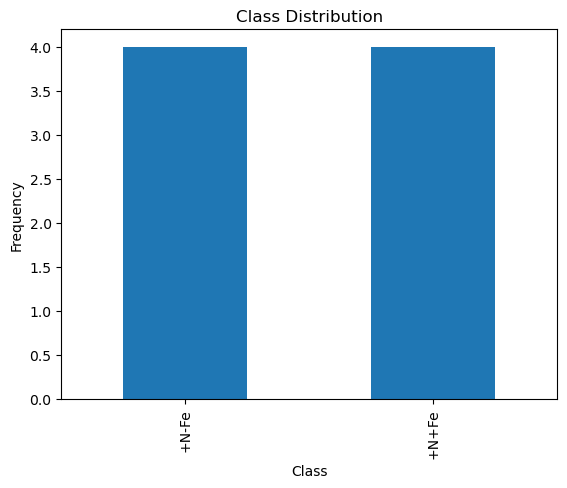

Columns with missing values: []
(8, 9)


In [146]:
# Step 1: Load the dataset
# Sheet 1
# test_df = pd.read_csv('Exp_I_Anna_Fe_Tomato.txt', delimiter='\t')
## Sheet 2
# test_df = pd.read_csv('Exp_II_Anna_Fe_Tomato.txt', delimiter='\t')
## Sheet 4
test_df = pd.read_csv('Exp_Marco_tesista_Fe_Lupino.txt', delimiter='\t')

## Note that in some of the sheets, there is a space after "Fe_deficiency" 
# Step 2: Preprocess the data
# Rename the column "Fe deficiency" to "Thesis"
test_df.rename(columns={'Fe_deficiency': 'Thesis'}, inplace=True)

# Verify the change
print(test_df.head())


# # Separate the dataset into features and labels
# 😎😎😎😎😎😎 new line, 1) include all Wavelengths
# X_te = test_df.iloc[:, 3:]
# 😎😎😎😎😎😎 new line, 2) remove nosiy Wavelengths
# X_te = test_df.iloc[:, 21:190]

# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
         #### Logistic Regression ###
# Anna1 Dataset, All Features, Logistic Regression
# desired_columns1 = ['714.55', '717.54', '985.05', '997.4', '994.31', '711.56', '978.88', '1000.49', '720.54']
# Anna1 Dataset, Some Features, Logistic Regression
# desired_columns1 = ['714.55', '711.56', '708.57', '720.54', '705.57', '723.53', '702.58', '750.54', '726.53']
# Anna1 Dataset, All Features, Random Forest
# desired_columns1 = ['705.57', '702.58', '708.57', '711.56', '714.55', '569.12', '542.68', '699.6', '545.62']
# Anna1 Dataset, Some Features, Random Forest
# desired_columns1 = ['714.55', '702.58', '711.56', '708.57', '705.57', '566.18', '699.6', '589.75', '580.9']

# For Anna2 Dataset, All Features, Logistic Regression
# desired_columns1 = ['714.55', '717.54', '985.05', '997.4', '711.56', '994.31', '978.88', '720.54', '708.57']
# For Anna2 Dataset, Some Features,Logistic Regression
# desired_columns1 = ['714.55', '711.56', '708.57', '720.54', '705.57', '723.53', '702.58', '750.54', '726.53']
# For Anna2 Dataset, All Features, Random Forest
# desired_columns1 = ['705.57', '702.58', '708.57', '711.56', '714.55', '569.12', '542.68', '699.6', '560.3']
# For Anna2 Dataset, Some Features, Random Forest
# desired_columns1 = ['714.55', '702.58', '711.56', '708.57', '705.57', '566.18', '699.6', '589.75', '580.9']

# For Marco1 Dataset, All Features, Logistic Regression
# desired_columns1 = ['985.05', '997.40', '994.31', '714.55', '717.54', '978.88', '1000.49', '711.56', '819.95']
# For Marco1 Dataset, Some Features,Logistic Regression
# desired_columns1 = ['714.55', '711.56', '708.57', '750.54', '720.54', '705.57', '723.53', '726.53', '702.58']
# For Marco1 Dataset, All Features, Random Forest
# desired_columns1 = ['705.57', '708.57', '702.58', '711.56', '714.55', '569.12', '699.60', '542.68', '560.30']
# For Marco1 Dataset, Some Features, Random Forest
desired_columns1 = ['714.55', '702.58', '708.57', '711.56', '705.57', '566.18', '699.60', '589.75', '580.90']

### Trimmed Versions ###
# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Anna1 Dataset, All Features, LogisticRegression
# desired_columns1 = ['714.55', '717.54', '711.56', '720.54', '708.57', '723.53', '726.53', '819.95', '729.53']
# For Anna1 Dataset, Some Features, Logistic Regression
# desired_columns1 = ['714.55', '753.55', '756.56', '717.54', '711.56', '708.57', '705.57', '720.54', '807.84']
# For Anna1 Dataset, All Features, Random Forest
# desired_columns1 = ['702.58', '714.55', '705.57', '708.57', '711.56', '717.54', '563.24', '542.68', '557.36']
# For Anna1 Dataset, Some Features, Random Forest
# desired_columns1 = ['711.56', '717.54', '708.57', '539.75', '545.62', '648.95', '702.58', '607.46', '554.43']

# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these state
# For Anna2 Dataset, All Features, LogisticRegression
# desired_columns1 = ['714.55', '717.54', '711.56', '708.57', '720.54', '723.53', '726.53', '729.53', '705.57']
# For Anna2 Dataset, Some Features, Logistic Regression
# desired_columns1 = ['714.55', '753.55', '756.56', '711.56', '717.54', '708.57', '705.57', '720.54', '807.84']
# For Anna2 Dataset, All Features, Random Forest
# desired_columns1 = ['702.58', '714.55', '705.57', '708.57', '711.56', '717.54', '563.24', '542.68', '557.36']
# For Anna2 Dataset, Some Features, Random Forest
# desired_columns1 = ['711.56', '717.54', '708.57', '539.75', '545.62', '702.58', '648.95', '607.46', '554.43']

# 😎😎😎😎😎😎 new line, 3) select only important Wavelengths introduced by SHAP, Remove "reduced-related" codes for these states
# For Marco1 Dataset, All Features, LogisticRegression
# desired_columns1 = ['714.55', '717.54', '711.56', '729.53', '708.57', '819.95', '726.53', '720.54', '750.54']
# For Marco1 Dataset, Some Features, Logistic Regression
# desired_columns1 = ['753.55', '756.56', '714.55', '717.54', '711.56', '708.57', '807.84', '705.57', '880.74']
# For Marco1 Dataset, All Features, Random Forest
# desired_columns1 = ['702.58', '714.55', '705.57', '708.57', '711.56', '717.54', '542.68', '563.24', '720.54']
# For Marco1 Dataset, Some Features, Random Forest
# desired_columns1 = ['711.56', '717.54', '708.57', '539.75', '545.62', '575.01', '648.95', '702.58', '607.46']
X_te= test_df[desired_columns1]

print("And now, let's see this dataframe's column names:")
print(X_te.columns)
# Ensure that X_te has the correct number of columns as X
X_te.columns = X.columns  # Update the column names to match those in X

y_te = test_df['Thesis']

# Check the distribution/imbalance of the target variable
class_distribution = test_df['Thesis'].value_counts()
# Print the class distribution
print("Class Distribution:")
print(class_distribution)
# Visualize the class distribution
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# # Encode the 'Thesis' column
le_te = LabelEncoder()
y_te = le_te.fit_transform(y_te)

# Check for missing values --> none
print(f"Columns with missing values: {test_df.columns[test_df.isnull().any()].tolist()}")

# Remove zero importance features from X_te
# X_reduced_te = X_te.drop(columns=zero_importance_features)
# feature_names_reduced = X_reduced_te.columns.tolist()
# print("\nX_reduced_te.shape is ", X_reduced_te.shape)
# print("\nX_reduced_te names.shape is ", len(feature_names_reduced))
# Scale the feature/columns values
scaler = StandardScaler()
# X_scaled_te = scaler.fit_transform(X_reduced_te)
X_scaled_te = scaler.fit_transform(X_te)
print(X_scaled_te.shape)



### Special For Miki 😃

In [8]:
# # Special For Miki 😃
# ## Sheet 3
# test_df_miki = pd.read_csv('Exp_4_Specie_Michele_Fe_and_N.txt', delimiter='\t')

# # Step 1: Map "Thesis" column values based on the encoding logic
# # +Fe (regardless of prefix) -> 0, -Fe (regardless of prefix) -> 1
# test_df_miki['Thesis'] = test_df_miki['Thesis'].apply(lambda x: 0 if '+Fe' in x else 1)

# # Verify the mapping
# print(test_df_miki[['Thesis']].head())

# # Step 2: Preprocess the data
# # Separate the dataset into features and labels
# X_te = test_df_miki.iloc[:, 4:]
# # Ensure that X_te has the correct number of columns as X
# X_te.columns = X.columns  # Update the column names to match those in X

# y_te = test_df_miki['Thesis']

# # Check the distribution/imbalance of the target variable
# class_distribution = test_df_miki['Thesis'].value_counts()
# # Print the class distribution
# print("Class Distribution:")
# print(class_distribution)

# # Visualize the class distribution
# class_distribution.plot(kind='bar')
# plt.title('Class Distribution')
# plt.xlabel('Class')
# plt.ylabel('Frequency')
# plt.show()

# # Check for missing values
# print(f"Columns with missing values: {test_df_miki.columns[test_df_miki.isnull().any()].tolist()}")


# # # Remove zero importance features from X_te
# # X_reduced_te = X_te.drop(columns=zero_importance_features)
# # feature_names_reduced = X_reduced_te.columns.tolist()
# # print("\nX_reduced_te.shape is ", X_reduced_te.shape)
# # print("\nX_reduced_te names.shape is ", len(feature_names_reduced))
# # # Scale the feature/columns values
# scaler = StandardScaler()
# # X_scaled_te = scaler.fit_transform(X_reduced_te)
# X_scaled_te = scaler.fit_transform(X_te)

# print(X_scaled_te.shape)
# # print(X_reduced_te.head())


### <font color=red> Disputed Cell! </font>
The following cell is related to "train & test" split which is under discussion
- Plan A: Blindly trust "train_test_split()" function
- Plan B: Manually, decompose the dataset based on plant type
- Plan C: <font color=red> 1) Use the train_test_split function to shuffle and split the data for each plant species separately. The split is set to 75% for training and 25% for testing --> each plant species has its own shuffled and split data, 2) Combine the Splits: combine the training subsets of (1) into a single training set and the test subsets into a single test set. </font>
- Plan D: Use "original dataset" as train and another (Anna1, Anna2, Marco1) set as Test

In [147]:
# # Step 3: Train-Test Split
# 😎😎😎😎😎😎 new line
# Plan D split
X_train, y_train = X_scaled, y
X_test, y_test = X_scaled_te, y_te

# Confirm the shape of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (144, 9), y_train shape: (144,)
X_test shape: (8, 9), y_test shape: (8,)


#### Very important
#### Check if encoded labels are consistant in original and each of the tested datasets

In [143]:
print("Label Encoding Mapping:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

print("Label Encoding Mapping:")
for i, label in enumerate(le_te.classes_):
    print(f"{label}: {i}")

# # Display the original and encoded values in the Thesis column
# print("Original and Encoded Thesis Labels:")
# test_df_miki['Original_Thesis'] = pd.read_csv('Exp_4_Specie_Michele_Fe_and_N.txt', delimiter='\t')['Thesis']  # Reload original data for comparison
# print(test_df_miki[['Original_Thesis', 'Thesis']].drop_duplicates())



Label Encoding Mapping:
+N+Fe: 0
+N-Fe: 1
Label Encoding Mapping:
+N+Fe: 0
+N-Fe: 1


#### Hyperparameter Tuning Using GridSearchCV , Model Training, and Evaluation
- Linear Logistic Regression </font>
- Randomforest

- <font color=red> Crossfold Validation in GridSearch (Hyperparameter tuning)</font>

#### <font color=green> Standard Logistic Regression </font>
#### Use it for plan auto, B, C, and D splits

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Cross-Validation Scores from GridSearchCV:
     mean_test_score  std_test_score  \
0          0.875862        0.142343   
1          0.868966        0.148556   
2          0.875862        0.142343   
3          0.896552        0.127166   
4          0.875862        0.142343   
5          0.903448        0.120245   
6          0.958621        0.066865   
7          0.944828        0.063956   
8          0.958621        0.066865   
9          0.972414        0.040213   
10         0.972414        0.040213   
11         0.972414        0.040213   
12         0.972414        0.040213   
13         0.972414        0.040213   
14         0.972414        0.040213   

                                               params  
0     {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}  
1   {'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...  
2       {'C': 0.01, 'penalty': 'l2', 'solver': 'sag'}  
3      {'C': 0.1, '

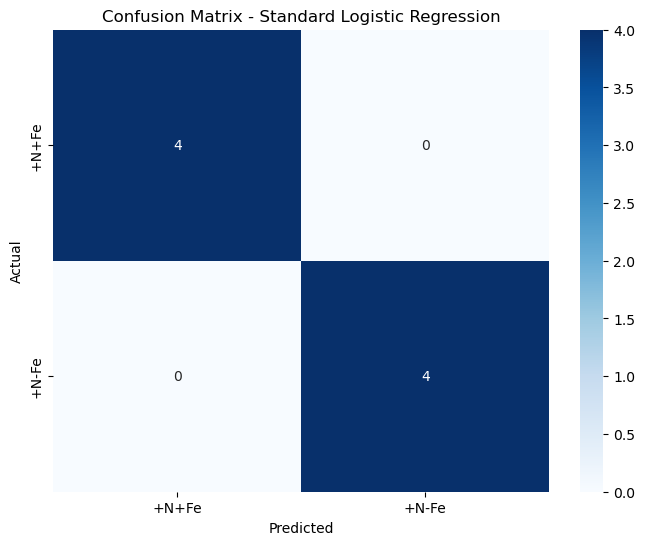

Linear Logistic Regression shap_values shape is (8, 9)


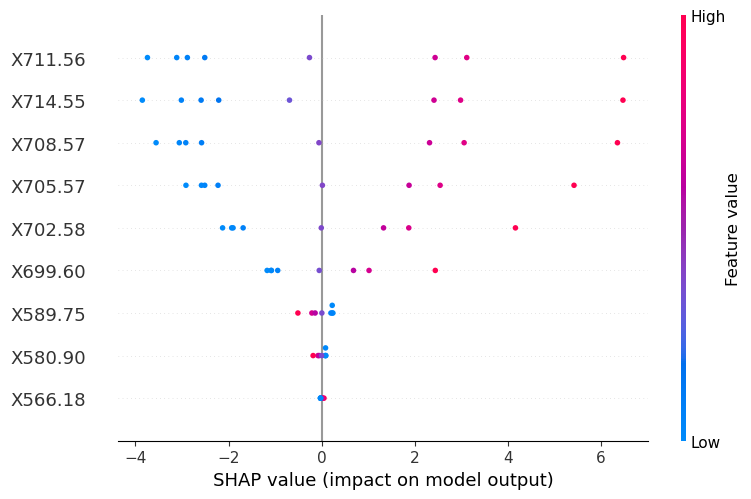

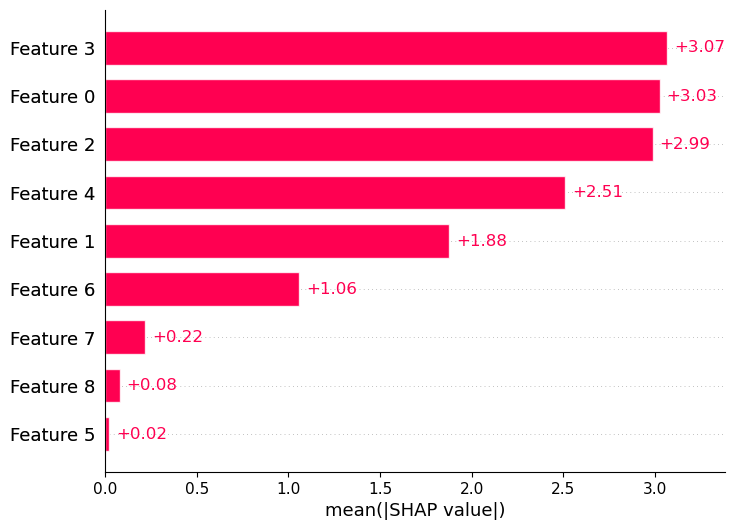

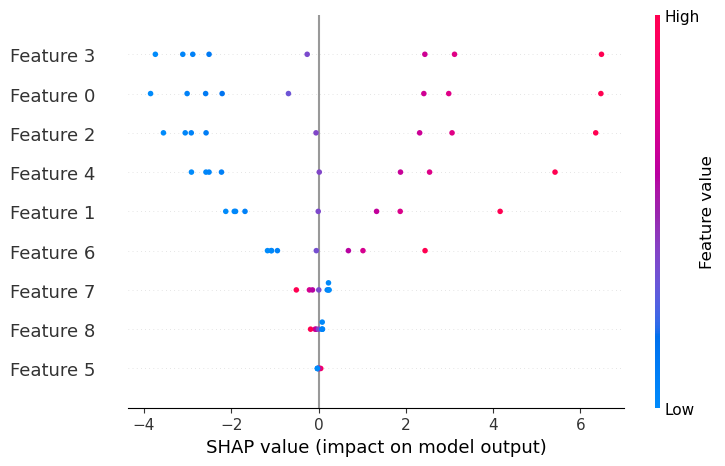

(8, 9)


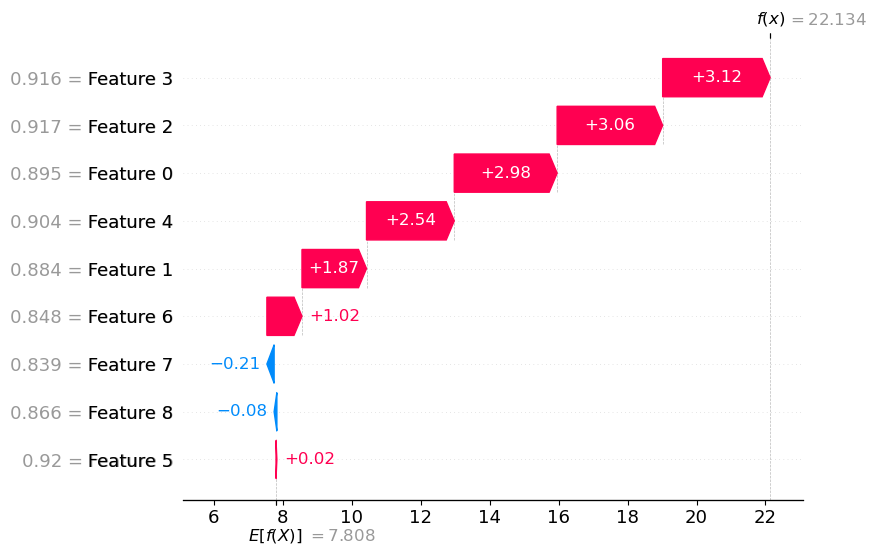

Model classes: [0 1]


In [148]:
### Hyperparameter Tuning and Cross-Validation for Standard Logistic Regression ###
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 30],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear', 'sag']
}
random_state= 42
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, tol=1e-3,random_state=random_state), param_grid_lr, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)
best_params_lr = grid_search_lr.best_params_
print("Best parameters for Logistic Regression:", best_params_lr)

# Print Cross-Validation Scores from GridSearchCV
cv_results = pd.DataFrame(grid_search_lr.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best logistic regression model
model = LogisticRegression(**best_params_lr, max_iter=5000, tol=1e-3, random_state=random_state)

# # Perform cross-validation
# cv_scores_lr = cross_val_score(model, X_train, y_train, cv=5)
# print("\nStandard Logistic Regression - Cross-Validation Scores:", cv_scores_lr)
# print("Mean Cross-Validation Score:", cv_scores_lr.mean())

# Train the model on the entire training set
model.fit(X_train, y_train)

# Extract coefficients and intercept
coefficients = model.coef_[0]  # For binary classification; adjust for multiclass
intercept = model.intercept_[0]  # For binary classification; adjust for multiclass
# Print coefficients and intercept with feature names
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
# Save the coefficients and intercept to a .txt file without rounding
output_file = "feature_coefficients_exact.txt"
with open(output_file, "w") as f:
    f.write(f"Intercept: {intercept}\n")
    f.write("Coefficients:\n")
    for feature, coef in zip(feature_names, coefficients):
        f.write(f"{feature}: {coef}\n")
print(f"Exact coefficients and intercept saved to {output_file}")

# Make predictions on the test set
y_pred = model.predict(X_scaled_te)

# Model Evaluation for Standard Logistic Regression
print("\nStandard Logistic Regression - Test Set Accuracy:", accuracy_score(y_te, y_pred))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred))

# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred_rf:", np.unique(y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",  xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Standard Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# NEW: SHAP ANALYSIS
# Use LinearExplainer for logistic regression
explainer_llr = shap.LinearExplainer(model, X_train)
# Calculate SHAP values
shap_values_llr = explainer_llr.shap_values(X_scaled_te)
print("Linear Logistic Regression shap_values shape is", np.shape(shap_values_llr))
# Ensure base_values is an array
base_values_llr = np.full(shap_values_llr.shape[0], explainer_llr.expected_value)
# Create an Explanation object
shap_values_llr_explanation = shap.Explanation(
    shap_values_llr,
    base_values=base_values_llr,
    data=X_scaled_te,
    # feature_names = feature_names_reduced
    # feature_names=feature_names
)
# Generate SHAP plots
# Summary Plot
shap.summary_plot(shap_values_llr, X_scaled_te, feature_names=feature_names)
# shap.summary_plot(shap_values_llr, X_scaled_te, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_llr_explanation, max_display=10)
# Beeswarm Plot
shap.plots.beeswarm(shap_values_llr_explanation)
print(shap_values_llr_explanation.shape)
# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_llr_explanation[1])

print("Model classes:", model.classes_)

#### Use the following cell as a <font color=red> "stand-alone Logistic Regression" </font> for plan C Prime split
#### run from the ast cell each time, or the sizes will collapse and it will engender error!

In [92]:
# # Function to train and evaluate a model, and compute SHAP values
# def train_evaluate_shap(X_train, y_train, X_test, y_test, feature_names):
#     # Define the parameter grid for Logistic Regression
#     param_grid_lr = {
#         'C': [0.01, 0.1, 1, 10, 30],
#         'penalty': ['l2'],
#         'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']  # Solvers that support multinomial
#     }

#     # Initialize the Logistic Regression model
#     lr_model = LogisticRegression(max_iter=1000, tol=1e-3, random_state=random_state)

#     # Perform GridSearchCV with cross-validation
#     grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, cv=5, scoring='accuracy')
#     grid_search_lr.fit(X_train, y_train)
#     best_params_lr = grid_search_lr.best_params_
#     print("Best parameters for Logistic Regression:", best_params_lr)

#     # Train the best model on the entire training set
#     best_lr_model = LogisticRegression(**best_params_lr, max_iter=1000, tol=1e-3, random_state=random_state)
#     best_lr_model.fit(X_train, y_train)

#     # Make predictions on the test set
#     y_pred = best_lr_model.predict(X_test)

#     # Evaluate the model
#     accuracy = accuracy_score(y_test, y_pred)
#     print("\nLogistic Regression - Test Set Accuracy:", accuracy)
#     print("Test Set Classification Report:")
#     print(classification_report(y_test, y_pred))

#     # Confusion Matrix
#     conf_matrix = confusion_matrix(y_test, y_pred)

#     # Calculate SHAP values
#     explainer = shap.Explainer(best_lr_model, X_train)
#     shap_values = explainer(X_test)
#     return accuracy, conf_matrix, y_test, y_pred, shap_values, feature_names


# # Initialize random state
# random_state = 42

# # Grouping the data by plant using X_scaled and y
# plant_groups_scaled = {
#     "Plant1": (X_scaled[0:36], y[0:36]),
#     "Plant2": (X_scaled[36:72], y[36:72]),
#     "Plant3": (X_scaled[72:108], y[72:108]),
#     "Plant4": (X_scaled[108:144], y[108:144])
# }

# # 😶😶😶😶😶😶😶😶😶😶😶😶
# # Shuffle the data for each plant once before starting the for loops
# for plant in plant_groups_scaled.keys():
#     X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
#     plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# # Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
# accuracies = []
# conf_matrices = []
# all_y_true = []
# all_y_pred = []
# shap_values_list = []

# # Number of splits
# n_splits = 4

# # Iterate to split the dataset
# for i in range(n_splits):
#     X_train_list = []
#     y_train_list = []
#     X_test_list = []
#     y_test_list = []

#     # Iterate over each plant species
#     for plant in plant_groups_scaled.keys():
#         X = plant_groups_scaled[plant][0]
#         y = plant_groups_scaled[plant][1]
        
#         # Define the indices for the current split
#         test_size = len(X) // n_splits
#         test_indices = range(i * test_size, (i + 1) * test_size)
#         train_indices = list(set(range(len(X))) - set(test_indices))
        
#         # Split the data for the current iteration
#         X_train_plant = X[train_indices]
#         y_train_plant = y[train_indices]
#         X_test_plant = X[test_indices]
#         y_test_plant = y[test_indices]
        
#         # Append to the respective lists
#         X_train_list.append(X_train_plant)
#         y_train_list.append(y_train_plant)
#         X_test_list.append(X_test_plant)
#         y_test_list.append(y_test_plant)

#     # Concatenate the lists to form the final train and test sets
#     X_train = np.concatenate(X_train_list, axis=0)
#     y_train = np.concatenate(y_train_list, axis=0)


#     # 😶😶😶😶😶😶😶😶😶😶😶😶
#     # Shuffle the concatenated train and test sets to remove any order-based bias
#     X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

#     # Confirm the shape of the train and test sets
#     print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
#     print(f"X_scaled_te shape: {X_scaled_te.shape}, y_te shape: {y_te.shape}")

#     # Train and evaluate the model, and get SHAP values
#     accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names = train_evaluate_shap(X_train, y_train, X_scaled_te, y_te, feature_names)
#     # accuracy, conf_matrix, y_true, y_pred, shap_values, feature_names = train_evaluate_shap(X_train, y_train, X_scaled_te, y_te, feature_names_reduced)
#     accuracies.append(accuracy)
#     conf_matrices.append(conf_matrix)
#     all_y_true.extend(y_true)
#     all_y_pred.extend(y_pred)
#     shap_values_list.append(shap_values)

#     # Plot the confusion matrix for each iteration
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
#     plt.title(f"Confusion Matrix - Iteration {i+1}")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.show()

# # Calculate the average accuracy
# average_accuracy = np.mean(accuracies)
# print("\nAverage Accuracy Across 4 Iterations:", average_accuracy)

# # Combine confusion matrices by summing them up
# combined_conf_matrix = np.sum(conf_matrices, axis=0)

# # Plot the combined confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(combined_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("Combined Confusion Matrix - Logistic Regression")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # Calculate precision, recall, and F1-score using the aggregated results
# precision = precision_score(all_y_true, all_y_pred, average='micro')
# recall = recall_score(all_y_true, all_y_pred, average='micro')
# f1 = f1_score(all_y_true, all_y_pred, average='micro')

# print(f"\nOverall Precision: {precision}")
# print(f"Overall Recall: {recall}")
# print(f"Overall F1-score: {f1}")

# # Aggregate SHAP values
# mean_shap_values = np.mean([sv.values for sv in shap_values_list], axis=0)
# combined_base_values = np.mean([sv.base_values for sv in shap_values_list], axis=0)

# # Assuming X_scaled_te from the last iteration, or a combined test set
# # Create an Explanation object with combined SHAP values
# combined_explanation = shap.Explanation(
#     values=mean_shap_values,
#     base_values=combined_base_values,
#     data=X_scaled_te,
#     feature_names=feature_names
#     # feature_names=feature_names_reduced
# )

# # Print the length of feature names in combined_explanation
# print("Length of feature names in combined_explanation:", len(combined_explanation.feature_names))

# # Generate SHAP plots for each class
# # Generate SHAP plots for binary classification or regression
# print("Generating SHAP plots for Binary Classification/Regression")

# # Summary Plot
# shap.summary_plot(
#     combined_explanation.values, 
#     X_scaled_te, 
#     feature_names=combined_explanation.feature_names
# )

# # Bar Plot
# shap.plots.bar(
#     shap.Explanation(
#         values=combined_explanation.values,
#         base_values=combined_explanation.base_values,
#         data=X_scaled_te,
#         feature_names=combined_explanation.feature_names
#     ), max_display=10
# )

# # Beeswarm Plot
# shap.plots.beeswarm(
#     shap.Explanation(
#         values=combined_explanation.values,
#         base_values=combined_explanation.base_values,
#         data=X_scaled_te,
#         feature_names=combined_explanation.feature_names
#     )
# )

# # Waterfall Plot for the first instance
# shap.plots.waterfall(
#     shap.Explanation(
#         values=combined_explanation.values[0],
#         base_values=combined_explanation.base_values[0],
#         data=X_scaled_te[0],
#         feature_names=combined_explanation.feature_names
#     )
# )


#### <font color=green> Random Forest </font>
#### Use it for plan auto, B, C, and D splits

C:\Users\hassa\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}

Cross-Validation Scores from GridSearchCV:
      mean_test_score  std_test_score  \
0           0.965271        0.037777   
1           0.965271        0.037777   
2           0.965271        0.037777   
3           0.965271        0.037777   
4           0.965271        0.037777   
..               ...             ...   
283         0.965271        0.037777   
284         0.965271        0.037777   
285         0.965271        0.037777   
286         0.965271        0.037777   
287         0.965271        0.037777   

                                                params  
0    {'max_depth': None, 'max_features': 'sqrt', 'm...  
1    {'max_depth': None, 'max_features': 'sqrt', 'm...  
2    {'max_depth': None, 'max_features': 'sqrt', 'm...  
3    {'max_depth': None, 'max_features': 'sqrt', 'm...  
4    {'max_depth': None, 'max_features': 's

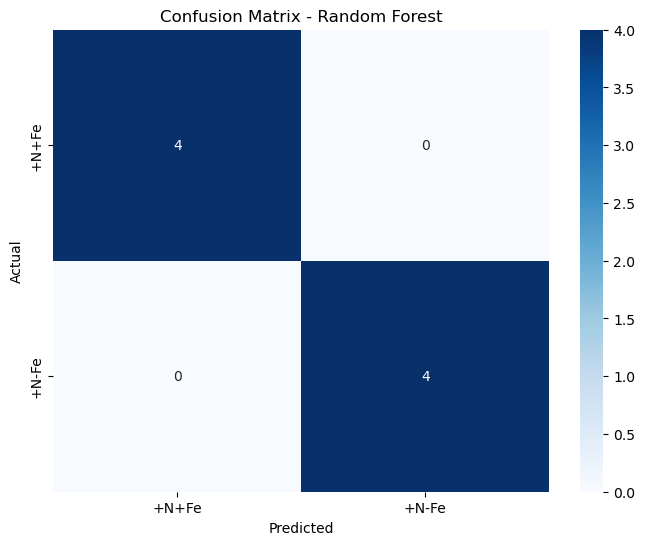

Random Forest shap_values shape is (8, 9, 2)
Selected SHAP values shape: (8, 9)


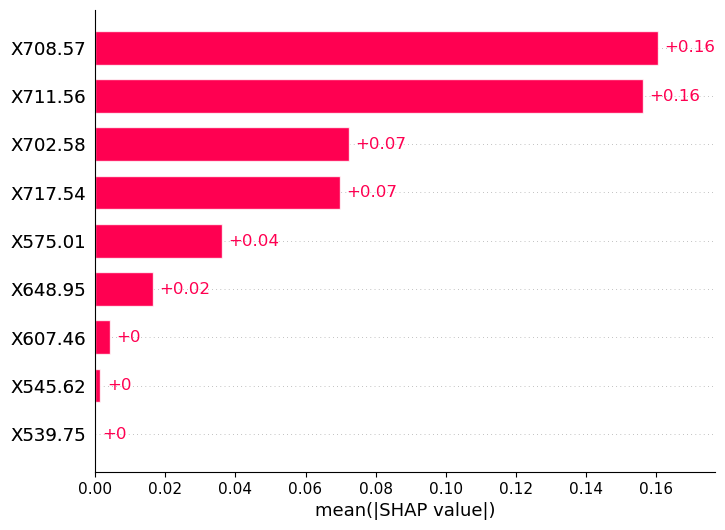

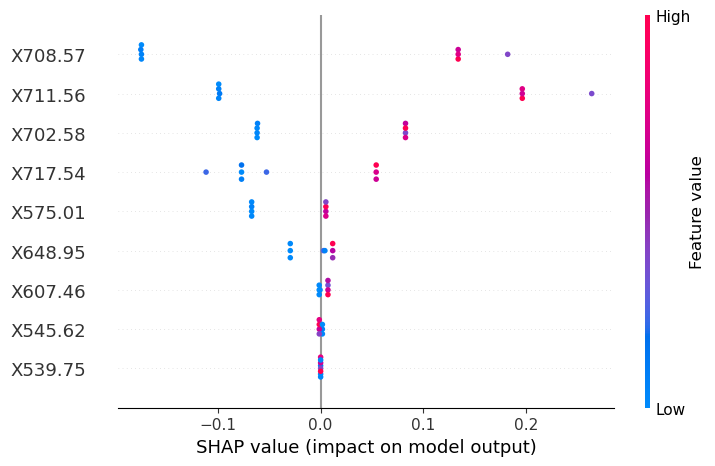

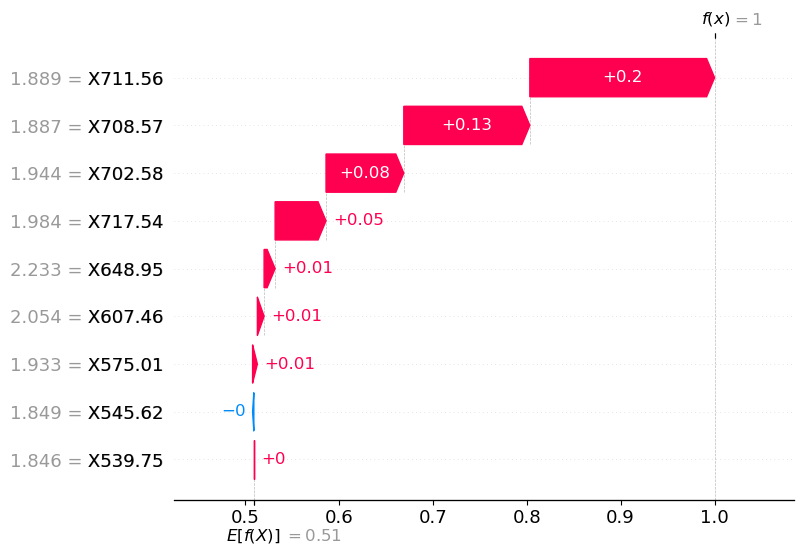

Model classes: [0 1]


In [133]:
### Random Forest Classifier ###
# Hyperparameter Tuning and Cross-Validation for Random Forest
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Set a random_state for reproducibility
random_state = 42
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_params_rf = grid_search_rf.best_params_
print("Best parameters for Random Forest:", best_params_rf)

# Print Cross-Validation Scores from GridSearchCV
cv_results_rf = pd.DataFrame(grid_search_rf.cv_results_)
print("\nCross-Validation Scores from GridSearchCV:\n", cv_results_rf[['mean_test_score', 'std_test_score', 'params']])

# Initialize the best Random Forest model
rf_model = RandomForestClassifier(**best_params_rf,random_state=random_state)

# Train the model on the entire training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_scaled_te)

# Model Evaluation for Random Forest
print("\nRandom Forest - Test Set Accuracy:", accuracy_score(y_te, y_pred_rf))
print("Test Set Classification Report:")
print(classification_report(y_te, y_pred_rf))

# make sure the labels match
print("Unique values in y_te:", np.unique(y_te))
print("Unique values in y_pred_rf:", np.unique(y_pred_rf))


# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_te, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["+N+Fe", "+N-Fe"], yticklabels=["+N+Fe", "+N-Fe"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SHAP Analysis
# Use TreeExplainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values_rf = explainer_rf.shap_values(X_scaled_te)
print("Random Forest shap_values shape is", np.shape(shap_values_rf))

# Select the SHAP values for the positive class (class 1)
shap_values_rf_selected = shap_values_rf[:, :, 1]
# Print the shape of the resulting array
print("Selected SHAP values shape:", shap_values_rf_selected.shape)

# Create an Explanation object
shap_values_rf_explanation = shap.Explanation(
    shap_values_rf_selected,
    base_values=explainer_rf.expected_value[1],  # Use the expected value of the positive class
    data=X_scaled_te,
    feature_names=feature_names
    # feature_names=feature_names_reduced
)

# Generate SHAP plots
# Summary Plot
# shap.summary_plot(shap_values_rf_explanation, X_scaled_te, feature_names=feature_names)
# shap.summary_plot(shap_values_rf_explanation, X_scaled_te, feature_names=feature_names_reduced)
# Bar Plot
shap.plots.bar(shap_values_rf_explanation)

# Beeswarm Plot
shap.plots.beeswarm(shap_values_rf_explanation)

# Waterfall Plot for the first instance
shap.plots.waterfall(shap_values_rf_explanation[0])

print("Model classes:", rf_model.classes_)

#### Use the following cell as a <font color=red> "stand-alone RandomForest" </font> for plan C Prime split
#### run from the ast cell each time, or the sizes will collapse and it will engender error!

In [ ]:
# # Function to train and evaluate a model, and compute SHAP values
# def train_evaluate_shap_rf(X_train, y_train, X_test, y_test, feature_names):
#     # Define the parameter grid for Random Forest
#     param_grid_rf = {
#         'n_estimators': [10, 50, 100, 200],
#         'max_depth': [None, 10, 20, 30],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'max_features': ['sqrt', 'log2']
#     }
#     random_state = 42

#     # Perform GridSearchCV with cross-validation
#     grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid_rf, cv=5, scoring='accuracy')
#     grid_search_rf.fit(X_train, y_train)
#     best_params_rf = grid_search_rf.best_params_
#     print("Best parameters for Random Forest:", best_params_rf)

#     # Initialize the best Random Forest model
#     best_rf_model = RandomForestClassifier(**best_params_rf, random_state=random_state)
#     best_rf_model.fit(X_train, y_train)

#     # Make predictions on the test set
#     y_pred_rf = best_rf_model.predict(X_test)

#     # Evaluate the model
#     accuracy_rf = accuracy_score(y_test, y_pred_rf)
#     print("\nRandom Forest - Test Set Accuracy:", accuracy_rf)
#     print("Test Set Classification Report:")
#     print(classification_report(y_test, y_pred_rf))

#     # Confusion Matrix
#     conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

#     # Calculate SHAP values using TreeExplainer
#     explainer_rf = shap.TreeExplainer(best_rf_model)
#     shap_values_rf = explainer_rf.shap_values(X_test)
#     print("shap_values_rf's shape", shap_values_rf.shape)
#     return accuracy_rf, conf_matrix_rf, y_test, y_pred_rf, shap_values_rf, explainer_rf, feature_names

# # Initialize random state
# random_state = 42

# # Grouping the data by plant using X_scaled and y
# plant_groups_scaled = {
#     "Plant1": (X_scaled[0:36], y[0:36]),
#     "Plant2": (X_scaled[36:72], y[36:72]),
#     "Plant3": (X_scaled[72:108], y[72:108]),
#     "Plant4": (X_scaled[108:144], y[108:144])
# }

# # 😶😶😶😶😶😶😶😶😶😶😶😶
# # Shuffle the data for each plant once before starting the for loops
# for plant in plant_groups_scaled.keys():
#     X, y = plant_groups_scaled[plant][0], plant_groups_scaled[plant][1]
#     plant_groups_scaled[plant] = shuffle(X, y, random_state=random_state)

# # Lists to store accuracies, confusion matrices, predictions, and SHAP values from each iteration
# accuracies_rf = []
# conf_matrices_rf = []
# all_y_true_rf = []
# all_y_pred_rf = []
# shap_values_list_rf = []
# explainer_rf_list = []

# # Number of splits
# n_splits = 4

# # Iterate to split the dataset
# for i in range(n_splits):
#     X_train_list = []
#     y_train_list = []
#     X_test_list = []
#     y_test_list = []

#     # Iterate over each plant species
#     for plant in plant_groups_scaled.keys():
#         X = plant_groups_scaled[plant][0]
#         y = plant_groups_scaled[plant][1]
        
#         # Define the indices for the current split
#         test_size = len(X) // n_splits
#         test_indices = range(i * test_size, (i + 1) * test_size)
#         train_indices = list(set(range(len(X))) - set(test_indices))
        
#         # Split the data for the current iteration
#         X_train_plant = X[train_indices]
#         y_train_plant = y[train_indices]
#         X_test_plant = X[test_indices]
#         y_test_plant = y[test_indices]
        
#         # Append to the respective lists
#         X_train_list.append(X_train_plant)
#         y_train_list.append(y_train_plant)
#         X_test_list.append(X_test_plant)
#         y_test_list.append(y_test_plant)

#     # Concatenate the lists to form the final train and test sets
#     X_train = np.concatenate(X_train_list, axis=0)
#     y_train = np.concatenate(y_train_list, axis=0)
  

#     # 😶😶😶😶😶😶😶😶😶😶😶😶
#     # Shuffle the concatenated train and test sets to remove any order-based bias
#     X_train, y_train = shuffle(X_train, y_train, random_state=random_state)

    
#     # Confirm the shape of the train and test sets
#     print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
#     print(f"X_scaled_te shape: {X_scaled_te.shape}, y_te shape: {y_te.shape}")

#     # Train and evaluate the model, and get SHAP values
#     accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_scaled_te, y_te, feature_names)
#     # accuracy_rf, conf_matrix_rf, y_true_rf, y_pred_rf, shap_values_rf, explainer_rf, feature_names = train_evaluate_shap_rf(X_train, y_train, X_scaled_te, y_te, feature_names_reduced)

    
#     accuracies_rf.append(accuracy_rf)
#     conf_matrices_rf.append(conf_matrix_rf)
#     all_y_true_rf.extend(y_true_rf)
#     all_y_pred_rf.extend(y_pred_rf)
#     shap_values_list_rf.append(shap_values_rf)
#     explainer_rf_list.append(explainer_rf)

#     # Plot the confusion matrix for each iteration
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
#     plt.title(f"Confusion Matrix - Iteration {i+1}")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.show()

# # Calculate the average accuracy
# average_accuracy_rf = np.mean(accuracies_rf)
# print("\nAverage Accuracy Across 4 Iterations:", average_accuracy_rf)

# # Combine confusion matrices by summing them up
# # Combine confusion matrices by summing them up
# combined_conf_matrix_rf = np.sum(conf_matrices_rf, axis=0)

# # Plot the combined confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(combined_conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
# plt.title("Combined Confusion Matrix - Random Forest")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # Calculate precision, recall, and F1-score using the aggregated results
# precision_rf = precision_score(all_y_true_rf, all_y_pred_rf, average='micro')
# recall_rf = recall_score(all_y_true_rf, all_y_pred_rf, average='micro')
# f1_rf = f1_score(all_y_true_rf, all_y_pred_rf, average='micro')

# print(f"\nOverall Precision: {precision_rf}")
# print(f"Overall Recall: {recall_rf}")
# print(f"Overall F1-score: {f1_rf}")

# # Aggregate SHAP values
# mean_shap_values_rf = np.mean([sv for sv in shap_values_list_rf], axis=0)
# combined_base_values_rf = np.mean([explainer.expected_value for explainer in explainer_rf_list], axis=0)
# print("combined_base_values_rf's shape", combined_base_values_rf)


# # Create an Explanation object with combined SHAP values
# combined_explanation_rf = shap.Explanation(
#     values=mean_shap_values_rf[:, :, 1],
#     base_values=combined_base_values_rf,
#     data=X_scaled_te,
#     feature_names=feature_names
#     # feature_names=feature_names_reduced
# )


# # Generate SHAP plots for each class
# print(f"Generating SHAP plots")
# # Summary Plot
# shap.summary_plot(combined_explanation_rf)
# # Bar Plot
# shap.plots.bar(combined_explanation_rf)
# # Beeswarm Plot
# shap.plots.beeswarm(combined_explanation_rf)
# # # Waterfall Plot for the first instance
# # shap.plots.waterfall(combined_explanation_rf[0])


### Plot the frequency of the features repeated in "All" and "Some" states extracted from the Trimmed Features-Feclassifier-all results.pptx

In [71]:
# import matplotlib.pyplot as plt
# from collections import Counter
# this code plots the ones in "reduced wavelengths"

# # series of spectrum in the following order
# ## Original-Auto, Original C prime, Anna1, Anna2, Marco, Merged, Marco2
# series = [
#     [708, 711],
#     [711, 714, 717],
#     [708, 711, 714, 717],
#     [705, 708, 711, 714, 717],
#     [708, 711, 714, 717, 720],
#     [705, 708, 711, 714, 717, 720],
#     [705, 708, 711, 714, 717]
# ]

# # Flatten the list of series and count the frequency of each number
# all_numbers = [num for sublist in series for num in sublist]
# frequency = Counter(all_numbers)

# # Prepare data for plotting
# numbers = list(frequency.keys())
# counts = list(frequency.values())

# # Plot the frequency
# plt.bar(numbers, counts, color='skyblue')
# plt.xlabel('Spectrum')
# plt.ylabel('Frequency')
# plt.title('When All Spectra is considered')
# plt.xticks(numbers)  # Ensures all numbers are shown on the x-axis
# plt.show()



# # series of spectrum in the following order
# ## Original-Auto, Original C prime, Anna1, Anna2, Marco, Merged, Marco2
# series2 = [
#     [702, 705, 708, 711, 714, 717],
#     [705, 708, 711, 714, 717],
#     [708, 711, 717],
#     [708, 711, 717],
#     [708, 711, 717],
#     [705, 708, 711, 714, 717, 720],
#     [702, 705, 711, 717],
# ]

# # Flatten the list of series and count the frequency of each number
# all_numbers2 = [num for sublist in series2 for num in sublist]
# frequency2 = Counter(all_numbers2)

# # Prepare data for plotting
# numbers2 = list(frequency2.keys())
# counts2 = list(frequency2.values())

# # Plot the frequency
# plt.bar(numbers2, counts2, color='blue')
# plt.xlabel('Spectrum')
# plt.ylabel('Frequency')
# plt.title('When Some Spectra is considered')
# plt.xticks(numbers2)  # Ensures all numbers are shown on the x-axis
# plt.show()

In [28]:
# import matplotlib.pyplot as plt
# from collections import Counter
# # this code plots the ones in "all wavelengths"

# # series of spectrum in the following order
# ## Original-Auto, Original C prime, Anna1, Anna2, Marco, Merged, Marco2
# series = [
#     [708, 711],
#     [711, 714],
#     [708, 711, 714],
#     [711, 714],
#     [708, 711, 714], 
#     [705, 708, 711, 714, 717, 720]
# ]

# # Flatten the list of series and count the frequency of each number
# all_numbers = [num for sublist in series for num in sublist]
# frequency = Counter(all_numbers)

# # Prepare data for plotting
# numbers = list(frequency.keys())
# counts = list(frequency.values())

# # Plot the frequency
# plt.bar(numbers, counts, color='skyblue')
# plt.xlabel('Spectrum')
# plt.ylabel('Frequency')
# plt.title('When All Spectra is considered')
# plt.xticks(numbers)  # Ensures all numbers are shown on the x-axis
# plt.show()



# # series of spectrum in the following order
# ## Original-Auto, Original C prime, Anna1, Anna2, Marco, Merged, Marco2
# series2 = [
#     [705, 708, 711, 714],
#     [705, 708, 711, 714],
#     [702, 705, 708, 711, 714],
#     [702, 705, 708, 711, 714],
#     [702, 705, 708, 711, 714],
#     [702, 705, 708, 711, 714],
#     [699, 702, 705, 708, 711, 714, 720]
# ]

# # Flatten the list of series and count the frequency of each number
# all_numbers2 = [num for sublist in series2 for num in sublist]
# frequency2 = Counter(all_numbers2)

# # Prepare data for plotting
# numbers2 = list(frequency2.keys())
# counts2 = list(frequency2.values())

# # Plot the frequency
# plt.bar(numbers2, counts2, color='blue')
# plt.xlabel('Spectrum')
# plt.ylabel('Frequency')
# plt.title('When Some Spectra is considered')
# plt.xticks(numbers2)  # Ensures all numbers are shown on the x-axis
# plt.show()